# Task 2.1.4: Task 4: Feature Extraction and Image Pyramids
## Techniques for feature extraction and image pyramids in object detection

The basic techniques for feature extraction and image pyramids in object detection. The aim is to understand the importance of feature extraction and how it ultimately determines the success of our object detection, as well as how image pyramids assist us in extracting features at different scales.

In [2]:
# Importing required libraries, which include:
# OpenCV library used for the many tasks in computer vision, from loading images, to processing, detecting, shapes, tracking objects etc.:
import cv2
# Numpy is very useful computation library, here we can use it to compute means:
import numpy as np
# We need the following to show images as plots (x and y axes), later we will use it to draw actual plots too:
import matplotlib.pyplot as plt
# We need the following to draw areas of interest on our plots and images:
import matplotlib.patches as patches

In [ ]:
# Load image and observe the different distinguishing features within images such as color, edges, and corners.

# Load the input image and convert to RGB
image = cv2.imread("data/sydney.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the output image
plt.imshow(image)
plt.show()

In [ ]:
# Feature extraction methods
# Implementing SIFT (Scale-Invariant Feature Transform) using OpenCV and detecting Keypoints within our image

# Load the input images in grayscale
image1 = cv2.imread("data/sydney.jpg", cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread("data/london.jpg", cv2.IMREAD_GRAYSCALE)

# Initialize the SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors for the images
keypoints1, descriptors1 = sift.detectAndCompute(image1, None)
keypoints2, descriptors2 = sift.detectAndCompute(image2, None)

# Visualize the keypoints on the images
image1_with_keypoints = cv2.drawKeypoints(image1, keypoints1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image2_with_keypoints = cv2.drawKeypoints(image2, keypoints2, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display the images with keypoints
plt.figure(figsize=(15, 15))
plt.subplot(1, 2, 1)
plt.imshow(image1_with_keypoints, cmap='gray')
plt.title('Image 1 with Keypoints')

plt.subplot(1, 2, 2)
plt.imshow(image2_with_keypoints, cmap='gray')
plt.title('Image 2 with Keypoints')

plt.tight_layout()
plt.show()

In the above images we can see the keypoints that SIFT detected. Most are located on corners and edges of the image. However, there are also some false-positives or outliers, these can then be filtered out in further steps by using an algorithm such as RANSAC.

In [ ]:
# Implementing ORB (Oriented FAST and Rotated BRIEF) using OpenCV and matching features within two different images of the same subject

# Load the input images in grayscale
image1 = cv2.imread("data/graf1.jpg")
image2 = cv2.imread("data/graf2.jpg")

# Convert the images to grayscale
gray_image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
gray_image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

# Initialize the ORB detector
orb = cv2.ORB_create()

# Detect keypoints and compute descriptors using ORB
keypoints1, descriptors1 = orb.detectAndCompute(gray_image1, None)
keypoints2, descriptors2 = orb.detectAndCompute(gray_image2, None)

# Create a BFMatcher object
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Perform matching using the descriptors
matches = bf.match(descriptors1, descriptors2)

# Sort the matches based on their distances
matches = sorted(matches, key=lambda x: x.distance)

# Draw the top 10 matches on the color images
result = cv2.drawMatches(image1, keypoints1, image2, keypoints2, matches[:10], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Convert the resulting image to RGB
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# Display the result
plt.figure(figsize=(15, 15))
plt.imshow(result_rgb)
plt.title('ORB Feature Matching')
plt.show()

Using the OpenCV library to compute the HOG features for an image of a person standing. The results are the gradients in each section of the image. The output of the HOG feature extraction can be manipulated by changeing the `blockSize`, `blockStride`, and `cellSize` attributes, as this affects the size of the cells that the gradients are computed on.

In [ ]:
# Implementing HOG (Histogram of Oriented Gradients) using OpenCV

# Load the input image
image = cv2.imread("data/person_standing.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize the image to a smaller size
image = cv2.resize(image, (64, 128))

# Initialize the HOG descriptor with specific parameters
winSize = (64, 128)
blockSize = (16, 16)
blockStride = (8, 8)
cellSize = (8, 8)
nbins = 9
hog = cv2.HOGDescriptor(winSize, blockSize, blockStride, cellSize, nbins)
#hog = cv2.HOGDescriptor()


# Compute HOG features
features = hog.compute(image)

# Reshape the features into a 1D array
features = features.flatten()

# Calculate the number of cells in each dimension
num_cells_x = image.shape[1] // cellSize[0]
num_cells_y = image.shape[0] // cellSize[1]

# Calculate the gradients for each cell
gradients = []
for y in range(num_cells_y):
    for x in range(num_cells_x):
        cell_features = features[(y * num_cells_x + x) * nbins: (y * num_cells_x + x + 1) * nbins]
        cell_gradients = np.array(cell_features).reshape(nbins, -1)
        gradients.append(cell_gradients)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot the original image
ax1.imshow(image)
ax1.set_title('Original Image')

# Plot the HOG gradients
ax2.set_title('HOG Gradients')

# Overlay the gradients as arrows
for y in range(num_cells_y):
    for x in range(num_cells_x):
        cell_gradients = gradients[y * num_cells_x + x]
        for i in range(nbins):
            angle = i * (180 / nbins)
            magnitude = cell_gradients[i, 0]
            dx = magnitude * np.cos(np.deg2rad(angle)) * 6  # Exaggerate the arrow lengths by a factor of 3
            dy = magnitude * np.sin(np.deg2rad(angle)) * 6  # Exaggerate the arrow lengths by a factor of 3
            ax2.arrow(x * cellSize[0] + cellSize[0] / 2, y * cellSize[1] + cellSize[1] / 2, dx, dy,
                      color='red', alpha=0.5, width=0.03, head_width=0.3, head_length=0.3)

# Adjust the limits of the axes to match the image dimensions
ax2.set_xlim(0, image.shape[1])
ax2.set_ylim(0, image.shape[0])

# Set the aspect ratio to be equal
ax2.set_aspect('equal')


plt.tight_layout()
plt.show()


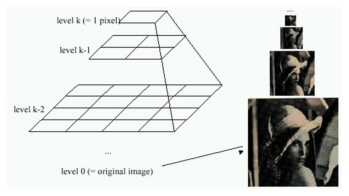

In [23]:
# Image Pyramids

# Load the input image and convert to RGB
image = cv2.imread("data/pyramid_lenna.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the output image
plt.imshow(image)
plt.axis('off')
plt.show()

In [ ]:
# Creating an image pyramid using downsampling

# Load the input image
image = cv2.imread("data/dog1.jpg")

# Create a copy of the original image
pyramid = image.copy()

# Display the original image
plt.figure()
plt.title("Level 0 - Original")
plt.imshow(cv2.cvtColor(pyramid, cv2.COLOR_BGR2RGB))
plt.show()

# Downscale the image and display each level
level = 1
while pyramid.shape[0] >= 25 and pyramid.shape[1] >= 25:
    pyramid = cv2.pyrDown(pyramid)

    # Display the downscaled image
    plt.figure()
    plt.title(f"Level {level}")
    plt.imshow(cv2.cvtColor(pyramid, cv2.COLOR_BGR2RGB))
    plt.show()

    level += 1

#### Hybrid Images

Using Gaussian and Laplcian pyramids, and the techniques of creating these pyramids by Gaussian blurring and Laplacian of Gaussian, we can create a very interesting effect called Hybrid Images.

In the example below, the low spatial scale is acquired by filtering one picture with a low-pass filter, while the high spatial scale is created by filtering a second image with a high-pass filter. These two filtered photos are combined to create the final hybrid image. From close-up this image looks like a tiger, but from far away we see an elephant instead.

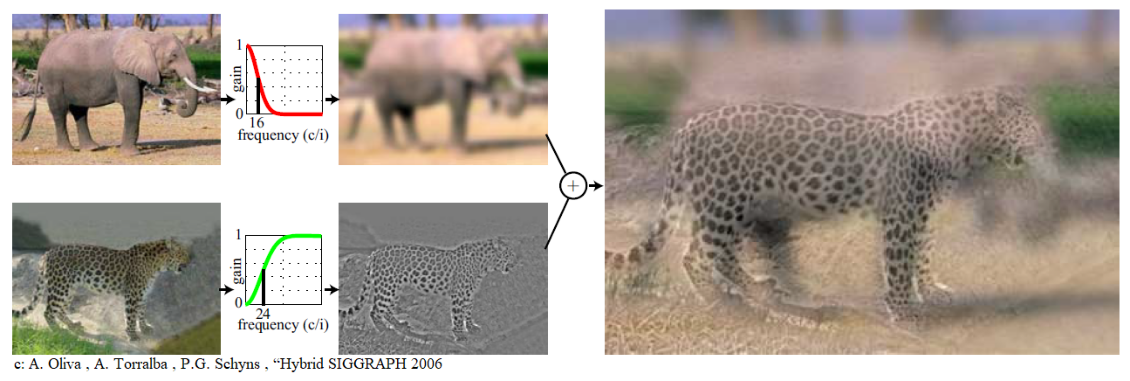

In [35]:
# Load the input image and convert to RGB
image = cv2.imread("data/hybrid_images.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the output image
plt.figure(figsize=(20,15))
plt.imshow(image)
plt.axis('off')
plt.show()

Task - Pick an image which has features at both larger and smaller scales. Use downsampling and upsampling to detect features within the image at different scales and interpret the results. How is this useful when implementing object detection algorithms?

In [1]:
# Notice how on the higher levels within the image pyramid, keypoints such as the blades of grass are recognized.
# Whereas in the lower levels of the image pyramid, such fine details are not detected.

# Load image

# Create an image pyramid

# Detect keypoints in each level of the pyramid

# Display results side by side
